<a href="https://colab.research.google.com/github/PeaceAndLongLife/Analysis-Colab/blob/Development/notebooks/Data_transcript_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data transcript analysis

<a href="https://colab.research.google.com/github/PeaceAndLongLife/Analysis-Colab/blob/Development/notebooks/Data_transcript_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup Google API

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# @title Load Git Repository {"form-width":"20%"}
clone_git = False # @param {"type":"boolean"}
if clone_git:
    !git clone https://github.com/PeaceAndLongLife/Analysis-Colab.git

import sys
from pathlib import Path
if '/content/Analysis-Colab/src' not in sys.path:
    sys.path.append('/content/Analysis-Colab/src')

pwd = !pwd
if pwd[0] != '/content/Analysis-Colab/notebooks':
  %cd /content/Analysis-Colab/notebooks

/content/Analysis-Colab/notebooks


In [4]:
# @title Mount google drive and read in the SERVICE_ACCOUNT_FILE  {"form-width":"20%"}

# @markdown ---
# @markdown
# @markdown The `SERVICE_ACCOUNT_FILE` path is stored as a secret in google colab. If you do not have this sotred on your colab, contact the Admin: Travis Kregear at tkregear@pdx.edu

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# load SERVICE_ACCOUNT_FILE
from google.colab import userdata

# !pip install PyDrive

import sys
# 2. Tell Python to look in your custom folder
sys.path.append('src')

SERVICE_ACCOUNT_FILE = userdata.get('SERVICE_ACCOUNT_FILE')
# SERVICE_ACCOUNT_FILE = '/content/drive/Shareddrives/Travis Research Drive/Interface 3.0/Admin files/service_account.json'

# 3. Import your file!
from GoogleFunctions import GoogleDocumentManager, extract_file_id
from local_io import read_csv_from_id


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The 'extract_file_id' function has been defined.


## Read in data

data read in will be merged using the `user` column

- consent file
- transcript data

In [5]:
# @title {"form-width":"20%"}

# @ title ## Input Data Links  {"form-width":"20%"}
# @markdown ---
# Consent data info
# @markdown Read in consent file {"form-width":"20%"}
consent_file_link = "https://drive.google.com/file/d/1wjpPGcbnFkO0tAOvwW5z-Isac4DVzPcv/view?usp=drive_link" # @param {"type":"string"}
consent_file_link_id = extract_file_id(consent_file_link)
show_consent = True # @param {"type":"boolean"}

# Transcript Data info
# @markdown Read in transcript file {"form-width":"20%"}
trans_file_link = "https://drive.google.com/file/d/1Q4G-RJAXd0GgkCyJpA8ajTXTk0hOyQhe/view?usp=drive_link" # @param {"type":"string"}
trans_file_link_id = extract_file_id(trans_file_link)
show_trans = True # @param {"type":"boolean"}
# @markdown ---
# @markdown Combine with 2nd transcript file {"form-width":"20%"}
combine_trans2 = True # @param {"type":"boolean"}
trans2_file_link = "https://drive.google.com/file/d/1rrv-K6od2GkgIw6GXeL-r0RvCaHMkZ9-/view?usp=drive_link" # @param {"type":"string"}
trans2_file_link_id = extract_file_id(trans2_file_link)
show_trans2 = True # @param {"type":"boolean"}
# @markdown ---
# @markdown Combine with 3rd transcript file {"form-width":"20%"}
combine_trans3 = False # @param {"type":"boolean"}
trans3_file_link = "" # @param {"type":"string"}
trans3_file_link_id = extract_file_id(trans3_file_link)
show_trans3 = False # @param {"type":"boolean"}

consent_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, consent_file_link_id, show_consent)
trans_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans_file_link_id, show_trans)
if combine_trans2:
  trans2_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans2_file_link_id, show_trans2)
if combine_trans3:
  trans3_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans3_file_link_id, show_trans3)
# @markdown ---
# display(trans_df)

Google Drive API service built successfully.
Reading in csv file. id=1wjpPGcbnFkO0tAOvwW5z-Isac4DVzPcv


,user,consent
0,241,False
1,141,True
2,156,True
3,115,False
4,177,True
...,...,...
221,275,False
222,306,False
223,318,True
224,341,True


Google Drive API service built successfully.
Reading in csv file. id=1Q4G-RJAXd0GgkCyJpA8ajTXTk0hOyQhe


,user,created_at,question,thread,model,personalityPrompt,prompt,all_messages
0,194,2025-10-04 03:02:32.694244+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0a9f2bcde0f87e180068e42671424c81988e2dff8...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do i answer these qu..."
1,126,2025-10-07 05:02:11.115686+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0c304934d3ea40cf0068e5b5b13d18819989044af...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""how do i submit all ..."
2,156,2025-09-30 03:41:36.520675+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0c7bb5598f9254020068e5e0a066b48198acc0a0a...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do these answers hav..."
3,115,2025-09-30 04:31:06.149084+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0505993b7950b07d0068de2258a398819b996942a...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""what is the THEORY f..."
4,149,2025-09-30 20:37:33.619255+00:00,"PH214 (online) - Assignment 1, Question: 4 - F...",resp_0026af49bf0edc580068e296104eac819a8715182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""The most minimum unc..."
...,...,...,...,...,...,...,...,...
1237,138,2025-11-30 21:45:02.513771+00:00,"PH214 (online) - Assignment 8, Question: 0 - H...",resp_04d9a749055e221500692cf9228354819885abd84...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": ""what is the learning..."
1238,159,2025-10-23 23:41:12.735939+00:00,"PH214 (online) - Assignment 4, Question: 0 - H...",resp_063b365b539862dc00693a2baa8844819a9aa758f...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do I mark where it l..."
1239,159,2025-10-23 23:41:12.754439+00:00,"PH214 (online) - Assignment 4, Question: 2 - U...",resp_05bfdd38a9fb2066006936448c72688196a488633...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""if \u0394y= 38 cm, \..."
1240,159,2025-10-23 23:41:12.772390+00:00,"PH214 (online) - Assignment 4, Question: 4 - W...",resp_0a31162129e6caa800693a29a07a208199b11eae4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""how do i find that v..."


Google Drive API service built successfully.
Reading in csv file. id=1rrv-K6od2GkgIw6GXeL-r0RvCaHMkZ9-


,user,created_at,question,thread,model,personalityPrompt,prompt,all_messages
0,136,2026-03-07 23:02:20.891090+00:00,PH215 (online) - Assignment 8 Question 0 - How...,resp_0bcdf01f104c99cd0069acb6e1c9648190bdecf19...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""how do i measure cur..."
1,341,2026-03-04 22:53:21.689288+00:00,PH216 - Assignment 6 Question 0 - How can I he...,resp_0403f83deaadc45c0069add15256a4819b99de7a6...,o4-mini-2025-04-16-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""I am worried that it..."
2,341,2026-03-04 22:54:18.774651+00:00,PH216 - Assignment 8 Question 0 - How can I he...,resp_029a63b1267430e30069ae165fca2c8199afb88dd...,o4-mini-2025-04-16-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""in step (7), why is ..."
3,188,2026-01-14 04:05:08.392795+00:00,PH215 (online) - Assignment 1 Question 0 - How...,resp_0f88106affd925350069671ae21408819a9a79bec...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""what data do i need ..."
4,256,2026-03-09 21:59:36.420831+00:00,PH215 (online) - Assignment 8 Question 0 - How...,resp_0c7007c627997b440069afa06831d08195984a302...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""I tried different si..."
...,...,...,...,...,...,...,...,...
588,281,2026-03-10 22:13:00.203009+00:00,PH215 (online) - Assignment 7 Question 2 - Wha...,resp_027b18091db822b20069b35ef0782481999c13d2a...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": "" In my experiment wh..."
589,281,2026-03-10 22:13:00.225722+00:00,PH215 (online) - Assignment 7 Question 6 - Mov...,resp_0b180a51ff973bce0069b37b36a434819a8643135...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": "" When the magnet is ..."
590,281,2026-03-10 22:13:00.231315+00:00,PH215 (online) - Assignment 7 Question 7 - Why...,resp_0b2e2596f70856a30069b3b33b85c48198a2dc9c4...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": ""It is necessary to p..."
591,281,2026-03-10 22:13:00.238127+00:00,PH215 (online) - Assignment 7 Question 8 - Wha...,resp_0c83f2dafe05167d0069b3b76e9ff48198a9ef2cf...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": "" Q8: As the current..."


In [6]:
# @title Process messages in transcript based on label pattern.
from data_scrub import process_messages, parse_messages, explode_json_messages
import pandas as pd
import re

###
# Merge consent into transcript
combined_df = process_messages(
    consent_df,
    trans_df,
    pattern = r"(.+) - Assignment (\d+), Question: (\d+) - (.+)",
)
if combine_trans2:
  combined2_df = process_messages(
      consent_df,
      trans2_df,
      pattern = r"(.+) - Assignment (\d+) Question (\d+) - (.+)",
  )
if combine_trans3:
  combined3_df = process_messages(
      consent_df,
      trans3_df,
      pattern = r"(.+) - Assignment (\d+) Question (\d+) - (.+)",
  )


Consent Data Combined into DataFrame.
 Question Data parsed and updated.
Consent Data Combined into DataFrame.
 Question Data parsed and updated.


In [7]:
# @title Combine transcripts
import pandas as pd

combined_df = pd.concat([combined_df, combined2_df], ignore_index=True)
display(combined_df.head())

,user,consent,created_at,question,thread,model,personalityPrompt,prompt,all_messages,Course,lab_number,question_number,question_text
0,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""is this question apa...",PH214 (online),02,01,"Calculate your average value of $\pi$, and the..."
1,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""The average value of...",PH214 (online),02,01,"Calculate your average value of $\pi$, and the..."
2,141,True,2025-10-06 20:20:05.231355+00:00,PH214 (online) - Lab 01-Q02,resp_04a0c6ece937672a0068e46907b7d4819a9cb5351...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": ""+ or - 1kg uncertain...",PH214 (online),01,02,"Based on the scale presented in Figure 1.2, ho..."
3,141,True,2025-10-06 20:20:05.237694+00:00,PH214 (online) - Lab 01-Q03,resp_0ab811549dde76ff0068e469c9dbc081949fc2d77...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": ""2.6 plus or minus 0....",PH214 (online),01,03,Report a fully detailed measurement (include t...
4,141,True,2025-10-06 20:20:05.244672+00:00,PH214 (online) - Lab 01-Q04,resp_096ad7ecad2d74570068e46b375d0c819a935200a...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": ""For 1.3 the minimum ...",PH214 (online),01,04,"For Figure 1.3, what is the minimum uncertaint..."


In [8]:
import numpy as np

users214 = combined_df[combined_df['Course']=="PH214 (online)"]['user'].unique()
users215 = combined_df[combined_df['Course']=="PH215 (online)"]['user'].unique()

common_users = np.intersect1d(users214, users215)
print(f"Number of common users in PH214 (online) and PH215 (online): {len(common_users)}")
display(common_users)

Number of common users in PH214 (online) and PH215 (online): 22


array([ 84,  99, 110, 122, 136, 137, 138, 139, 156, 159, 174, 182, 188,
       201, 222, 233, 234, 237, 239, 244, 256, 260])

In [9]:
# @title parse and explode trans
from data_scrub import process_messages, parse_messages, explode_json_messages
import pandas as pd
import re
# Apply the parsing function to the 'all_messages' column
combined_df['all_messages'] = combined_df['all_messages'].apply(parse_messages)

# Count message objects in 'all_messages' and add to 'interactions' column
combined_df['interactions'] = combined_df['all_messages'].apply(lambda x: len(x) / 2)

combined_df = combined_df[combined_df['all_messages'].apply(lambda x: len(x) > 0)]

print("Combined DataFrame with split question columns and interactions:")
# display(combined_df.head())
unexploded_df = combined_df.copy()
combined_df = explode_json_messages(combined_df)
display(unexploded_df.head())

Combined DataFrame with split question columns and interactions:


,user,consent,created_at,question,thread,model,personalityPrompt,prompt,all_messages,Course,lab_number,question_number,question_text,interactions
0,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{'data': False, 'text': 'is this question apa...",PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",1.0
1,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{'data': False, 'text': 'The average value of...",PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",1.0
2,141,True,2025-10-06 20:20:05.231355+00:00,PH214 (online) - Lab 01-Q02,resp_04a0c6ece937672a0068e46907b7d4819a9cb5351...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{'data': False, 'text': '+ or - 1kg uncertain...",PH214 (online),01,02,"Based on the scale presented in Figure 1.2, ho...",3.0
3,141,True,2025-10-06 20:20:05.237694+00:00,PH214 (online) - Lab 01-Q03,resp_0ab811549dde76ff0068e469c9dbc081949fc2d77...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{'data': False, 'text': '2.6 plus or minus 0....",PH214 (online),01,03,Report a fully detailed measurement (include t...,3.0
4,141,True,2025-10-06 20:20:05.244672+00:00,PH214 (online) - Lab 01-Q04,resp_096ad7ecad2d74570068e46b375d0c819a935200a...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{'data': False, 'text': 'For 1.3 the minimum ...",PH214 (online),01,04,"For Figure 1.3, what is the minimum uncertaint...",1.0


In [10]:
num_duplicates = combined_df.duplicated().sum()

print(f"Number of duplicate rows in combined_df: {num_duplicates}")

if num_duplicates > 0:
    print("Displaying duplicate rows:")
    display(combined_df[combined_df.duplicated(keep=False)].sort_values(by=list(combined_df.columns)))
else:
    print("No duplicate rows found.")

Number of duplicate rows in combined_df: 0
No duplicate rows found.


## Analysis

In [11]:
# @title Filter by Consent? {"form-width":"20%"}
FilterConsented = True # @param {"type":"boolean"}

if FilterConsented:
  unexploded_df = unexploded_df[unexploded_df['consent'] == True]
  combined_df = combined_df[combined_df['consent'] == True]


In [12]:
# @title Remove 216
remove_216 = True # @param {"type":"boolean"}
if remove_216:
  unexploded_df = unexploded_df[unexploded_df['Course'] != 'PH216']
  combined_df = combined_df[combined_df['Course'] != 'PH216']

### Analysis Functions

In [13]:
# @title analyze_stats function
def analyze_hist(df, drop_counts_under_param,y,x):
  # Exclude users with less than drop_counts_under_param unique threads
  df_filtered = df[df[y] >= drop_counts_under_param]


  ### Plot distribution
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Set the style for the plot
  sns.set_style("whitegrid")

  plt.figure(figsize=(10, 6))
  sns.histplot(df_filtered[y], bins=50, kde=True)
  plt.title(f"Distribution of {y} per {x}")
  plt.xlabel(f"{x}")
  # plt.ylabel(f"Number of {y}")
  plt.tight_layout()
  plt.show()
  display(df_filtered[y].describe())


In [14]:
def analyze_bar_graph(df, x_col, y_col, title="Bar Graph Distribution", x_label=None, y_label=None, tick_label_size=10):
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Set the style for the plot
  sns.set_style("whitegrid")

  plt.figure(figsize=(12, 6))
  ax = sns.barplot(x=x_col, y=y_col, data=df.sort_values(by=y_col, ascending=False))

  # Add labels and title
  if x_label is None:
    x_label = x_col.replace('_', ' ').title()
  if y_label is None:
    y_label = y_col.replace('_', ' ').title()

  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)

  # Ensure x-axis labels are always horizontal
  plt.xticks(rotation=90)

  # Adjust tick label size
  plt.tick_params(axis='x', labelsize=tick_label_size)
  plt.tick_params(axis='y', labelsize=tick_label_size)

  # Add numbers on top of the bars
  for p in ax.patches:
      ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                  textcoords='offset points')

  plt.tight_layout()
  plt.show()

In [15]:
# @title export_data_csv
def export_data_csv(df, output_df_name,folder_link):
  folder_id = extract_file_id(folder_link)
  gdm = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)
  output_filename = f"{output_df_name}.csv"

  if not folder_id:
    print(f"Error: No target folder ID provided for '{output_filename}'. Please enter a valid Google Drive Folder ID.")
    return
  try:
      uploaded_file_id = gdm.upload_dataframe_to_drive(df, output_filename, folder_id, include_index=False)

      if uploaded_file_id:
          print(f"Successfully saved '{output_df_name}' DataFrame to '{output_filename}'. File ID: {uploaded_file_id}")

      else:
          print(f"Failed to upload '{output_df_name}' DataFrame to '{output_filename}'. See previous error messages.")
  except Exception as e:
      print(f"Error saving '{output_df_name}' DataFrame to '{output_filename}': {e}")
  return


  ###
  # Example implementation

  ## @markdown ---
# export_table = False # @param {"type":"boolean"}
# output_name = "conversations_by_question" # @param {"type":"string","placeholder":"Enter the name of the csv file"}
# target_folder_link = "https://drive.google.com/drive/folders/1Jz9QrU0ZmhCQn4GWh_wa9WtUPzcW2s-s?usp=drive_link" # @param {"type":"string","placeholder":"Enter YOUR_GOOGLE_DRIVE_FOLDER_ID_HERE"}

# if export_table:
#   export_data_csv(df,output_name, target_folder_link)

### Analysis Criteria


--- Histogram for Course: PH214 (online) ---


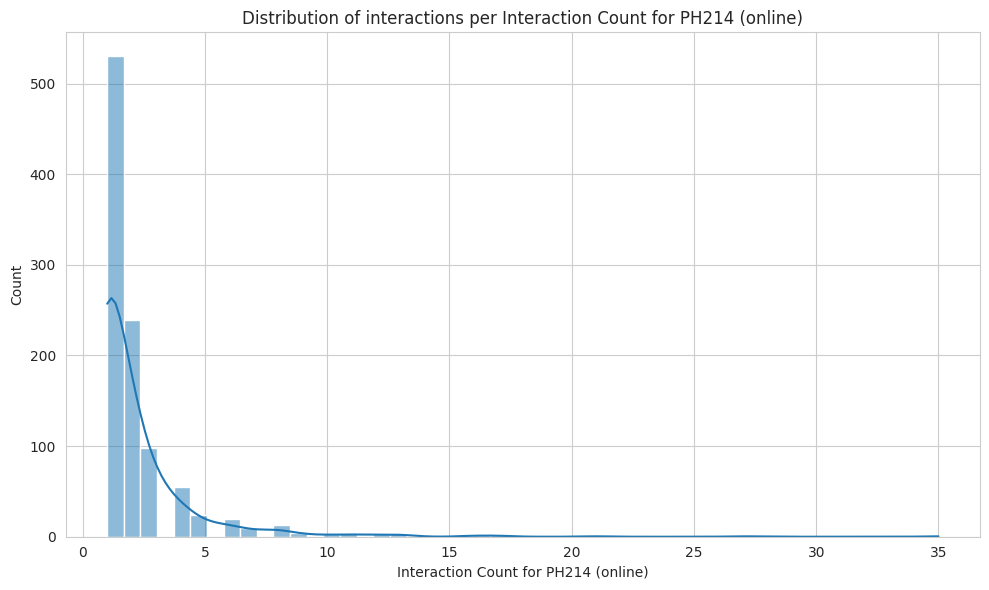

,interactions
count,1014.000000
mean,2.251479
std,2.523507
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,35.000000



--- Histogram for Course: PH215 (online) ---


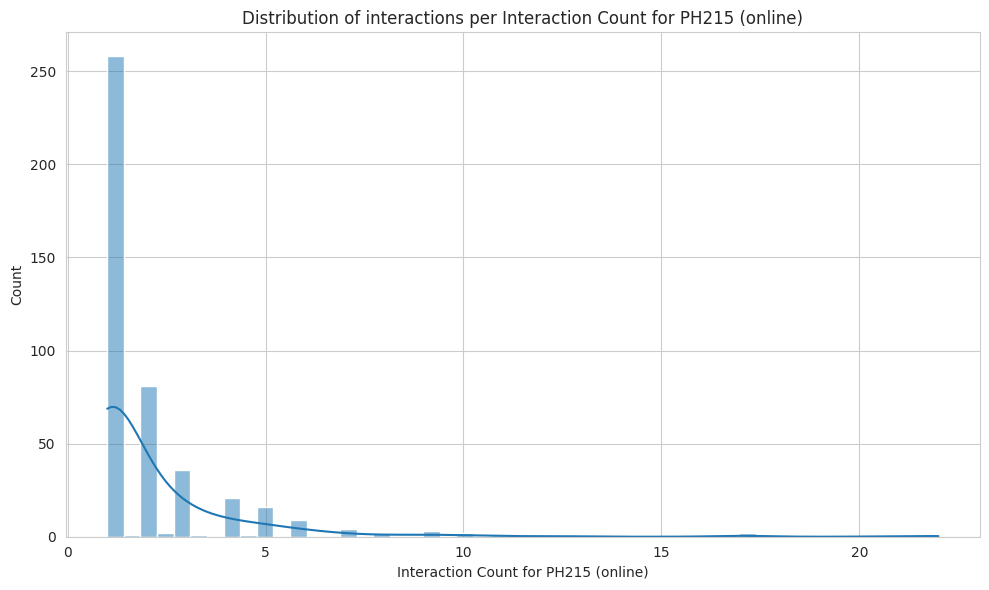

,interactions
count,443.000000
mean,2.148984
std,2.385224
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,22.000000


In [16]:
# @title Histogram of all interactions {'run': 'auto', 'form-width': '20%'}

# By default, not dropping any counts under a certain threshold
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}

# Get unique courses from the unexploded_df
unique_courses = unexploded_df['Course'].unique()

for course in unique_courses:
  print(f"\n--- Histogram for Course: {course} ---")
  # Filter the DataFrame for the current course
  df_course = unexploded_df[unexploded_df['Course'] == course]
  # Call the analyze_hist function to plot the distribution of interactions for the current course
  analyze_hist(df_course, drop_counts_under, 'interactions', f'Interaction Count for {course}')

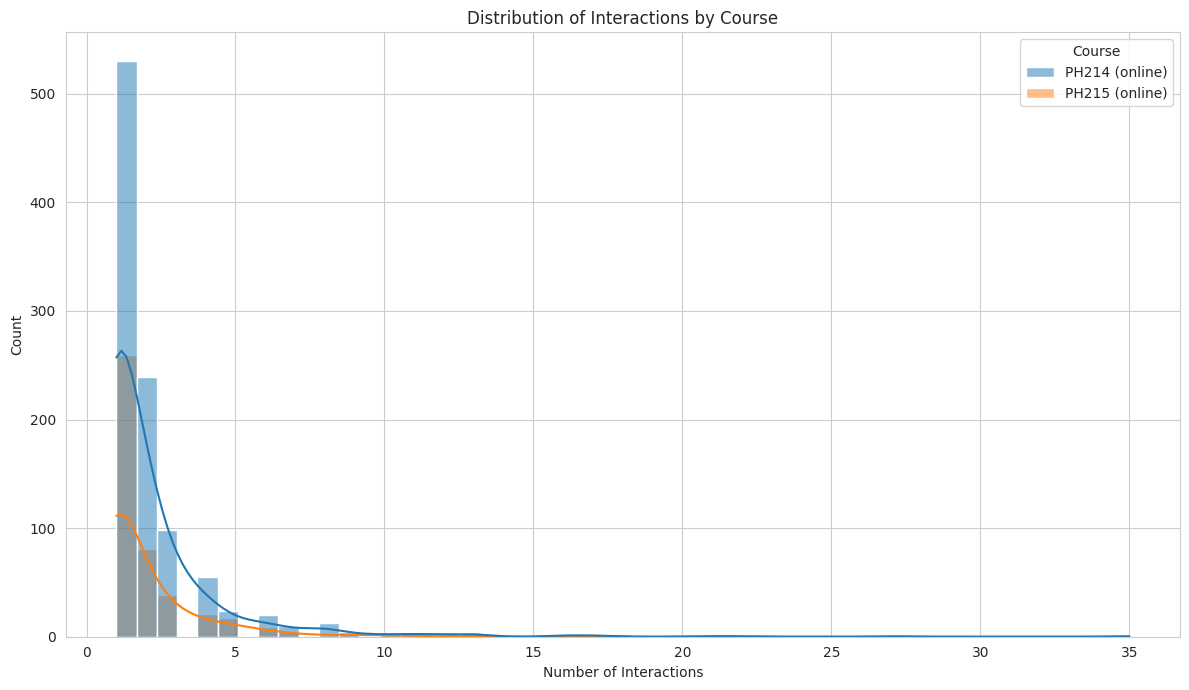

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))
sns.histplot(data=unexploded_df, x='interactions', hue='Course', bins=50, kde=True)
plt.title('Distribution of Interactions by Course')
plt.xlabel('Number of Interactions')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [18]:
# @title Make Groups {"form-width":"20%"}
# Course_name = "PH214 (online)" # @param ["PH214 (online)","PH215 (online)"] {"allow-input":true}
df_course = unexploded_df

# df_course = unexploded_df[unexploded_df['Course'] == Course_name]

# # x>40
# group4 = df_course[(df_course['interactions']>20)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
# print(f"above 20 interactions. count: {len(group4)}")
# display(group4)


# print("----\n\n")
# # 20<=x<40
# group3 = df_course[(df_course['interactions']<=20) & (df_course['interactions']>9)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
# print(f"Between 9 and 20 interactions. count: {len(group3)}")
# display(group3)

# print("----\n\n")
# # 2<x<=19
# group2 = df_course[(df_course['interactions']<=9) & (df_course['interactions']>5)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
# print(f"Between 5 and 9 interactions. count: {len(group2)}")
# display(group2)

# print("----\n\n")
# # 2<x<=6
# group5 = df_course[(df_course['interactions']<=5) & (df_course['interactions']>2)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
# print(f"Between 2 and 5 interactions. count: {len(group5)}")
# display(group5)

# print("----\n\n")
# # 2>=x
# group1 = df_course[df_course['interactions']<=2][['user','Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
# print(f"Less than 12 interactions. count: {len(group1)}")
# display(group1)

display(df_course[(df_course['interactions']>=1)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False))
# display(df_course[(df_course['user'].isin([139,256,159,203,245,160,331,237,149,252,181])) & (df_course['interactions']>=6)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False))
# display(df_course[(df_course['interactions']>=7)]['interactions'])
# display(df_course[(df_course['interactions']>=1)]['interactions'].describe())
display(df_course[(df_course['interactions']>=7)]['user'].sort_values().unique())
display(df_course[df_course['Course'] == 'PH214 (online)'].describe())
display(df_course[df_course['Course'] == 'PH215 (online)'].describe())
# display(df_course['interactions'].describe())


,user,Course,lab_number,question_number,interactions
816,159,PH214 (online),05,00,35.0
491,240,PH214 (online),05,00,27.0
1283,237,PH215 (online),05,00,22.0
1324,256,PH215 (online),01,08,21.0
757,256,PH214 (online),02,01,21.0
...,...,...,...,...,...
1127,215,PH214 (online),06,01,1.0
1123,215,PH214 (online),04,04,1.0
1122,215,PH214 (online),04,02,1.0
1121,215,PH214 (online),03,08,1.0


array([ 91,  93,  95,  98, 101, 106, 139, 144, 149, 159, 160, 203, 209,
       215, 219, 222, 225, 234, 237, 239, 240, 243, 256, 261, 263, 281,
       301, 305, 333])

,user,interactions
count,1014.000000,1014.000000
mean,176.340237,2.251479
std,57.266661,2.523507
min,78.000000,1.000000
25%,132.500000,1.000000
50%,181.000000,1.000000
75%,234.000000,2.000000
max,267.000000,35.000000


,user,interactions
count,443.000000,443.000000
mean,257.690745,2.148984
std,74.405071,2.385224
min,84.000000,1.000000
25%,159.000000,1.000000
50%,281.000000,1.000000
75%,325.000000,2.000000
max,339.000000,22.000000


In [19]:

# @title export md to Drive {"form-width":"20%"}
drive_folder_link = "https://drive.google.com/drive/folders/1414llqKBFaCDzhKRWAMvZNQeAGQ5LTz_?usp=drive_link" # @param {"type":"string"}
drive_folder_id = extract_file_id(drive_folder_link)
export_md_file = False # @param {"type":"boolean"}
user_num = "333" # @param {"type":"string","placeholder":"Enter user number here"}
notes = "" # @param {"type":"string","placeholder":"Enter Observation notes here"}

table_user = df_course[(df_course['user']==int(user_num))][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
# display(table_user)

if export_md_file:
  # Initialize selected_doc_url and selected_sheet_url if they are not defined
  # This handles the case where the cell is run before a specific lab is selected



  header_blocks=[
        f"User: {user_num}",
        f"Course: {Course_name}",
        "\n---\n\n"
        ]

  header_str = "\n".join(header_blocks)
  table_str = table_user.to_markdown(index=False)

  markdown_text = f"# Transcript Report\n\n{header_str}\n\n## User interactions by lab\n\n{table_str}\n\n Notes:\n\n{notes}"
  filename = f"{user_num}-{Course_name}.md"

  # Upload to Google Drive if drive_folder_id is provided

  gdm = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)
  gdm.export_md(markdown_text, filename, drive_folder_id)
  print("file exported")
else:
  print("no file exported")

no file exported


In [20]:
display(table_user['interactions'].sum())

np.float64(39.0)

In [21]:
# @title count conversations by question {"form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown the x axis represents the question sorted by lab, then number.

current_df = combined_df

thread_counts_df = current_df.groupby(['Course', 'lab_number', 'question_number', 'question', ])['thread'].nunique().reset_index().sort_values(by=['lab_number', 'question_number'])
thread_counts_df.rename(columns={'thread': 'unique_thread_count'}, inplace=True)
# thread_counts_df = thread_counts_df.sort_values(by=['question'])
print("Unique user counts per question:")
# analyze_bar_graph(thread_counts_df, 'question', 'unique_thread_count', 'Conversation Count by Question', tick_label_size=7)
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique user counts per question:


,Course,lab_number,question_number,question,unique_thread_count
1,PH214 (online),01,01,PH214 (online) - Lab 01-Q01,61
2,PH214 (online),01,02,PH214 (online) - Lab 01-Q02,46
4,PH214 (online),01,04,PH214 (online) - Lab 01-Q04,40
3,PH214 (online),01,03,PH214 (online) - Lab 01-Q03,39
5,PH214 (online),01,05,PH214 (online) - Lab 01-Q05,35
...,...,...,...,...,...
99,PH215 (online),03,00,PH215 (online) - Lab 03-Q00,3
91,PH215 (online),02,09,PH215 (online) - Lab 02-Q09,2
12,PH214 (online),02,00,PH214 (online) - Lab 02-Q00,2
108,PH215 (online),04,02,PH215 (online) - Lab 04-Q02,2


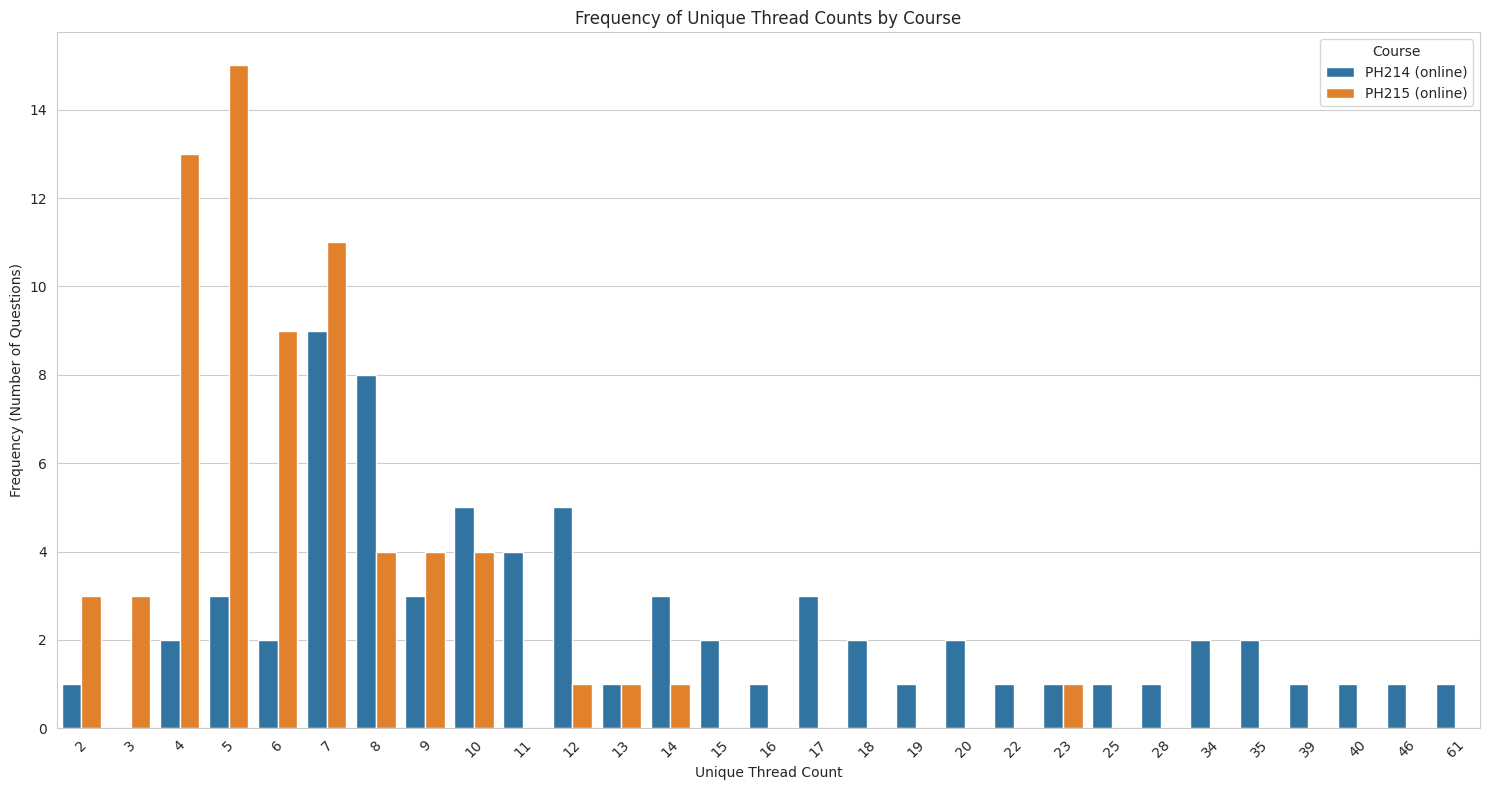

,Course,lab_number,question_number,question,unique_thread_count
1,PH214 (online),01,01,PH214 (online) - Lab 01-Q01,61
2,PH214 (online),01,02,PH214 (online) - Lab 01-Q02,46
4,PH214 (online),01,04,PH214 (online) - Lab 01-Q04,40
3,PH214 (online),01,03,PH214 (online) - Lab 01-Q03,39
5,PH214 (online),01,05,PH214 (online) - Lab 01-Q05,35
...,...,...,...,...,...
99,PH215 (online),03,00,PH215 (online) - Lab 03-Q00,3
91,PH215 (online),02,09,PH215 (online) - Lab 02-Q09,2
12,PH214 (online),02,00,PH214 (online) - Lab 02-Q00,2
108,PH215 (online),04,02,PH215 (online) - Lab 04-Q02,2


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

# Preprocess data to count frequencies for barplot
barplot_data = thread_counts_df.groupby(['Course', 'unique_thread_count']).size().reset_index(name='frequency')

plt.figure(figsize=(15, 8))
sns.barplot(data=barplot_data, x='unique_thread_count', y='frequency', hue='Course', dodge=True)
plt.title('Frequency of Unique Thread Counts by Course')
plt.xlabel('Unique Thread Count')
plt.ylabel('Frequency (Number of Questions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique user counts per lab:


,Course,lab_number,unique_thread_count
0,PH214 (online),01,405
1,PH214 (online),02,160
8,PH215 (online),01,130
5,PH214 (online),06,122
6,PH214 (online),07,107
3,PH214 (online),04,96
2,PH214 (online),03,94
9,PH215 (online),02,87
13,PH215 (online),06,74
14,PH215 (online),07,53


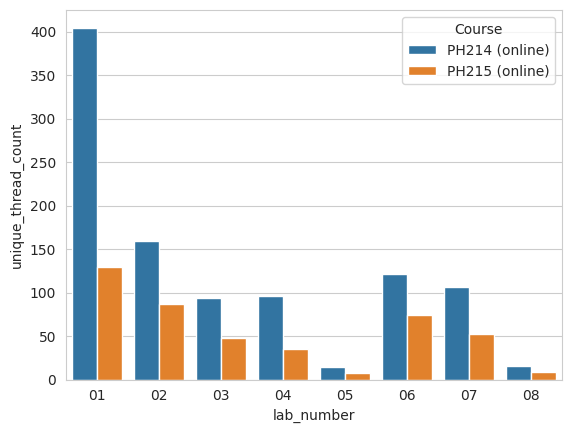

In [23]:
# @title count conversations by lab_number {"form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown the x axis represents the lab number.

current_df = combined_df

thread_counts_df = current_df.groupby(['Course', 'lab_number'])['thread'].nunique().reset_index().sort_values(by=['lab_number'])
thread_counts_df.rename(columns={'thread': 'unique_thread_count'}, inplace=True)
# thread_counts_df = thread_counts_df.sort_values(by=['question'])
print("Unique user counts per lab:")
sns.barplot(data=thread_counts_df, x='lab_number', y='unique_thread_count', hue='Course', dodge=True)
# analyze_bar_graph(thread_counts_df, 'lab_number', 'unique_thread_count', 'Conversation Count by Question', tick_label_size=7)
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique thread counts per user and lab_number:


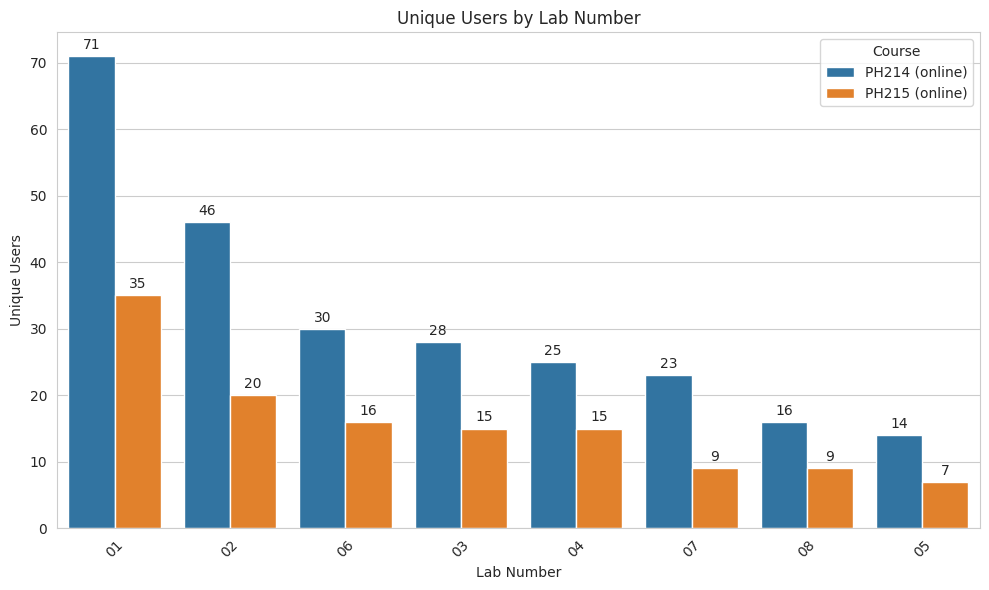

,Course,lab_number,unique_users
0,PH214 (online),01,71
1,PH214 (online),02,46
8,PH215 (online),01,35
5,PH214 (online),06,30
2,PH214 (online),03,28
3,PH214 (online),04,25
6,PH214 (online),07,23
9,PH215 (online),02,20
13,PH215 (online),06,16
7,PH214 (online),08,16


In [24]:
# @title count users per lab {"form-width":"20%"}

current_df = combined_df

lab_counts_df = current_df.groupby(['Course', 'lab_number'])['user'].nunique().reset_index()
lab_counts_df.rename(columns={'user': 'unique_users'}, inplace=True)
lab_counts_df = lab_counts_df[['Course', 'lab_number','unique_users']].sort_values(by=['unique_users'], ascending=False)
print("Unique thread counts per user and lab_number:")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=lab_counts_df, x='lab_number', y='unique_users', hue='Course', dodge=True)

# Add numbers on top of the bars
ax = plt.gca()
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(patch.get_x() + patch.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.title('Unique Users by Lab Number')
plt.xlabel('Lab Number')
plt.ylabel('Unique Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# analyze_bar_graph(lab_counts_df,'lab_number', 'unique_users', "Unique users by Lab numbers")
display(lab_counts_df)

Unique thread per user


,user,unique_threads
76,252,63
121,331,63
86,139,60
30,139,59
75,245,55
...,...,...
84,136,1
68,235,1
110,312,1
102,278,1


----


greater or equal to 45 conversations. count: 5


,user,unique_threads
76,252,63
121,331,63
86,139,60
30,139,59
75,245,55


----


Between 22 and 45 conversations. count: 14


...

,user,unique_threads
4,85,21
43,174,21
17,106,20
20,111,20
87,156,18
80,263,17
71,239,17
8,91,17
59,219,16
112,314,16


----


Between 5 and 13 conversations. count: 38


,user,unique_threads
60,222,12
49,188,12
13,101,12
115,318,12
118,325,12
31,141,12
36,151,12
9,92,11
122,332,11
77,256,11


----


Less than 5. count: 53


,user,unique_threads
34,147,4
83,122,4
108,301,4
96,237,4
98,244,4
41,167,4
7,90,4
56,209,3
111,313,3
2,83,3


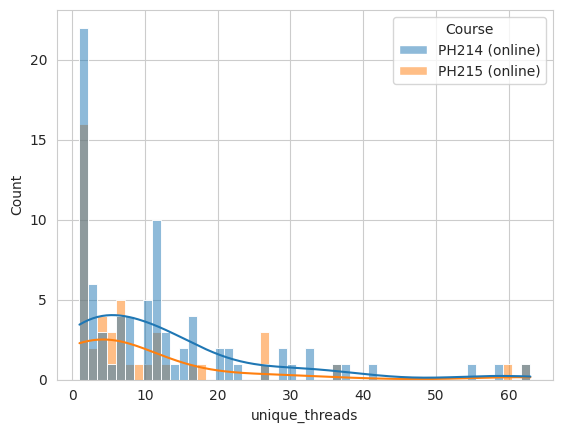

In [25]:
# @title count conversations by user {"run":"auto","form-width":"20%"}

drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown "4 groups: x<5, 5<x<13, 13<x<22, 22<x<45, 45<x"
filter_by_lab_number = "False" # @param ["01","02","03","04","05","06","07","08","False"] {"allow-input":true}

# Call the function with the relevant DataFrame and parameter

current_df = combined_df
if filter_by_lab_number != "False":
  current_df = current_df[current_df['lab_number'] < filter_by_lab_number]

lab_counts_df = current_df.groupby(['Course','user'])['thread'].nunique().reset_index()
lab_counts_df.rename(columns={'thread': 'unique_threads'}, inplace=True)

lab_counts_df = lab_counts_df.sort_values(by='unique_threads', ascending=False)

print("Unique thread per user")
import ipywidgets as widgets
from IPython.display import display

# analyze_hist(lab_counts_df, drop_counts_under,'unique_threads','user'
# analyze_hist(lab_counts_df, drop_counts_under,'unique_threads','user')
sns.histplot(data=lab_counts_df, x='unique_threads', hue='Course', bins=50, kde=True)

# analyze_bar_graph(lab_counts_df,'user', 'unique_threads', "Unique threads per user")
display(lab_counts_df[['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False))

print("----\n\n")
# x>=45
group5 = lab_counts_df[lab_counts_df['unique_threads']>=45][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"greater or equal to 45 conversations. count: {len(group5)}")
display(group5)

print("----\n\n")
# 22<=x<45
group4 = lab_counts_df[(lab_counts_df['unique_threads']<45) & (lab_counts_df['unique_threads']>=22)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 22 and 45 conversations. count: {len(group4)}")
display(group4)


print("----\n\n")
# 13<=x<22
group3 = lab_counts_df[(lab_counts_df['unique_threads']<22) & (lab_counts_df['unique_threads']>=13)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 13 and 22 conversations. count: {len(group3)}")
display(group3)

print("----\n\n")
# 5<=x<13
group2 = lab_counts_df[(lab_counts_df['unique_threads']<13) & (lab_counts_df['unique_threads']>=5)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 5 and 13 conversations. count: {len(group2)}")
display(group2)

print("----\n\n")
# 5>x
group1 = lab_counts_df[lab_counts_df['unique_threads']<5][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Less than 5. count: {len(group1)}")
display(group1)


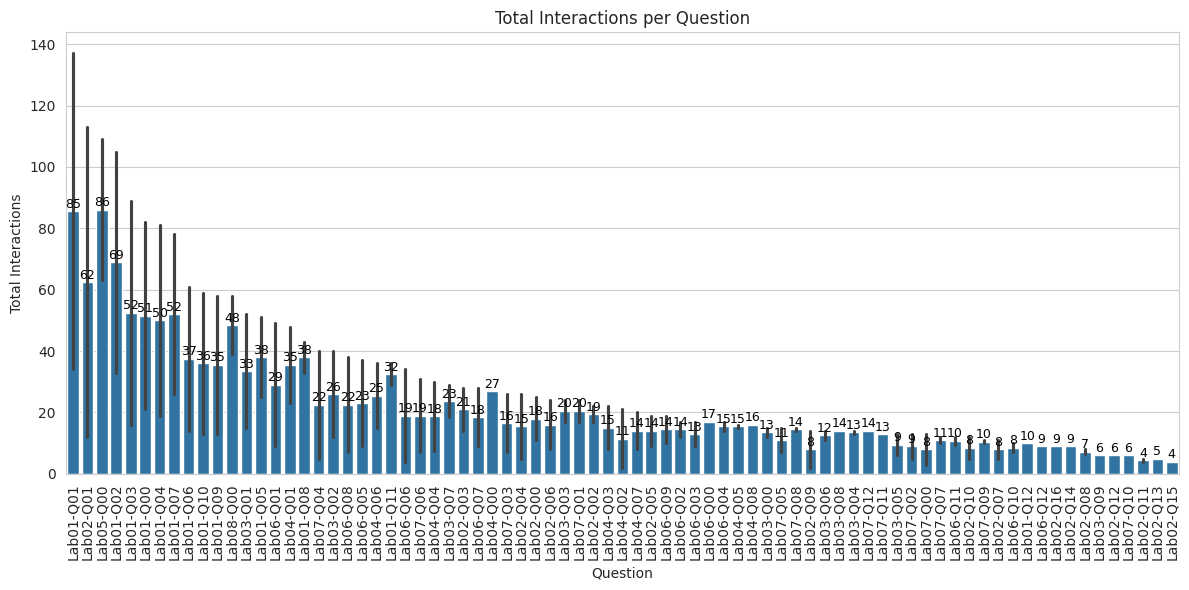

,full_question,interactions
1,Lab01-Q01,137.0
13,Lab02-Q01,113.0
43,Lab05-Q00,109.0
2,Lab01-Q02,105.0
3,Lab01-Q03,89.0
...,...,...
97,Lab02-Q15,4.0
121,Lab06-Q06,4.0
128,Lab07-Q00,3.0
91,Lab02-Q09,2.0


In [26]:
# @title Total Interactions by Question Plot {"form-width":"20%"}

current_df = unexploded_df

interactions_by_question = current_df.groupby(['Course', 'lab_number', 'question_number', 'question_text'])['interactions'].sum().reset_index()

# Create a combined question identifier for the x-axis labels if needed, or use existing columns
interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
analyze_bar_graph(
    df=interactions_by_question,
    x_col='full_question',
    y_col='interactions',
    title='Total Interactions per Question',
    x_label='Question',
    y_label='Total Interactions'
)
interactions_by_question = interactions_by_question.sort_values(by='interactions', ascending=False)
display(interactions_by_question[['full_question','interactions']])


# @markdown ---
export_table = False # @param {"type":"boolean"}
output_name = "conversations_by_question" # @param {"type":"string","placeholder":"Enter the name of the csv file"}
target_folder_link = "https://drive.google.com/drive/folders/1Jz9QrU0ZmhCQn4GWh_wa9WtUPzcW2s-s?usp=drive_link" # @param {"type":"string","placeholder":"Enter YOUR_GOOGLE_DRIVE_FOLDER_ID_HERE"}

if export_table:
  export_data_csv(interactions_by_question[['full_question','interactions']],output_name, target_folder_link)

In [27]:
display(current_df[(current_df['user']== 256)]['interactions'].sum())

np.float64(215.0)

Total interactions for each user by course:


Course,user,PH214 (online),PH215 (online),Total Interactions
30,139,106.0,125.0,231.0
77,256,66.0,149.0,215.0
39,159,114.0,52.5,166.5
54,203,165.0,0.0,165.0
75,245,100.0,0.0,100.0
...,...,...,...,...
47,183,1.0,0.0,1.0
48,185,1.0,0.0,1.0
58,217,1.0,0.0,1.0
91,312,0.0,1.0,1.0


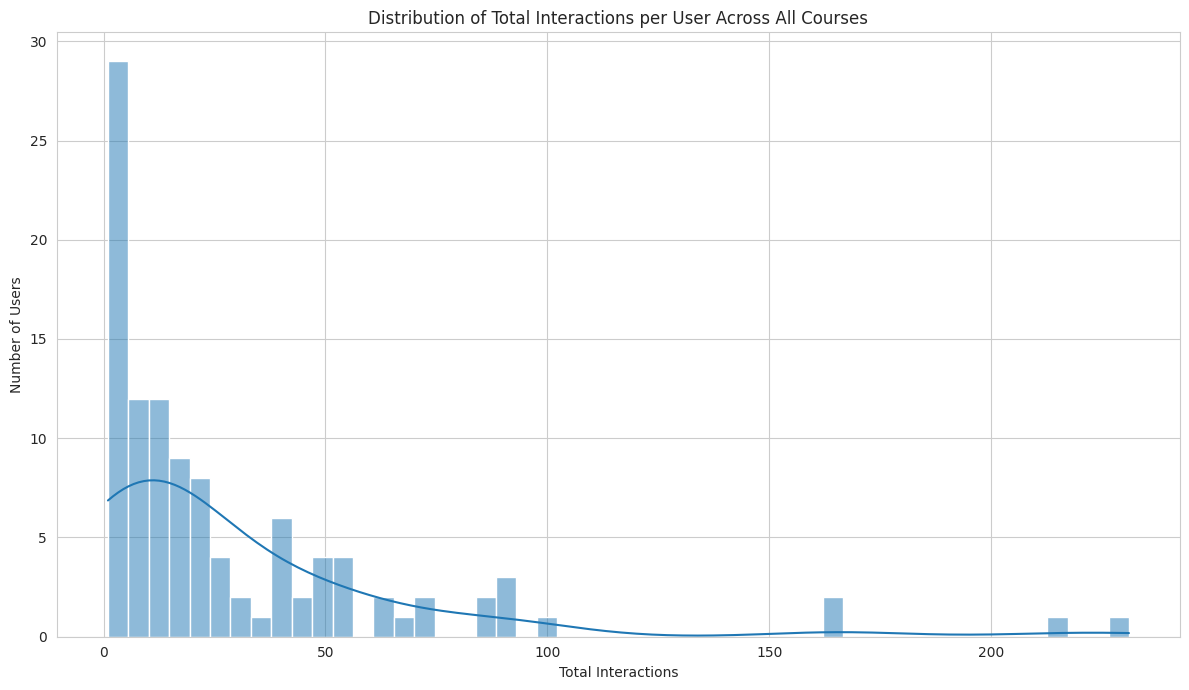

In [28]:
# @title Total Interactions by User and Course

current_df = unexploded_df

# Calculate interactions per user per course
interactions_by_user_and_course = current_df.groupby(['user', 'Course'])['interactions'].sum().reset_index()

# Pivot the table to have courses as columns
interactions_pivot = interactions_by_user_and_course.pivot_table(
    index='user',
    columns='Course',
    values='interactions',
    fill_value=0 # Fill NaN values with 0 for users who didn't interact in a specific course
).reset_index()

# Calculate the total interactions for each user across all courses
interactions_pivot['Total Interactions'] = interactions_pivot[unexploded_df['Course'].unique()].sum(axis=1)

# Sort by total interactions
interactions_pivot = interactions_pivot.sort_values(by='Total Interactions', ascending=False)

print("Total interactions for each user by course:")
display(interactions_pivot)

# Plot distribution of total interactions per user
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))
sns.histplot(data=interactions_pivot, x='Total Interactions', bins=50, kde=True)
plt.title('Distribution of Total Interactions per User Across All Courses')
plt.xlabel('Total Interactions')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

# Store total interactions for potential further use
interactions_by_user = interactions_pivot[['user', 'Total Interactions']]

In [29]:
display(interactions_pivot['Total Interactions'].describe())
# display(interactions_pivot[(interactions_pivot['PH214 (online)']!=int(0)) & (interactions_pivot['PH215 (online)']!=int(0))]['Total Interactions'].describe())

# display(interactions_pivot['PH214 (online)'].describe())

,Total Interactions
count,108.000000
mean,29.953704
std,40.994275
min,1.000000
25%,5.000000
50%,15.500000
75%,41.000000
max,231.000000


In [30]:
print("List of users with >=71 total interactions\n")
display(interactions_by_user[interactions_by_user['Total Interactions']>=71])
print("---\n\n")

print("List of users with >=50 interactions in PH214\n")
display(interactions_pivot[interactions_pivot['PH214 (online)']>=50][['user','PH214 (online)']])
print("---\n\n")

print("List of users with >=32 interactions in PH215\n")
display(interactions_pivot[interactions_pivot['PH215 (online)']>=30][['user','PH215 (online)']])
print("---\n\n")


List of users with >=71 total interactions



Course,user,Total Interactions
30,139,231.0
77,256,215.0
39,159,166.5
54,203,165.0
75,245,100.0
40,160,92.0
102,331,91.0
70,237,88.5
35,149,88.0
76,252,87.0


---


List of users with >=50 interactions in PH214



Course,user,PH214 (online)
30,139,106.0
77,256,66.0
39,159,114.0
54,203,165.0
75,245,100.0
40,160,92.0
70,237,52.0
35,149,88.0
76,252,87.0
45,181,72.0


---


List of users with >=32 interactions in PH215



Course,user,PH215 (online)
30,139,125.0
77,256,149.0
39,159,52.5
102,331,91.0
70,237,36.5
90,305,55.5
84,281,44.0
38,156,31.0
104,333,39.0
88,298,36.0


---




In [31]:
import pandas as pd

desc_ph214 = interactions_pivot['PH214 (online)'].describe().rename('PH214 (online)')
desc_ph215 = interactions_pivot['PH215 (online)'].describe().rename('PH215 (online)')
desc_total = interactions_pivot['Total Interactions'].describe().rename('Total Interactions')

merged_descriptions = pd.concat([desc_ph214, desc_ph215, desc_total], axis=1)
display(merged_descriptions.round(2))

,PH214 (online),PH215 (online),Total Interactions
count,108.00,108.00,108.00
mean,21.14,8.81,29.95
std,30.17,22.69,40.99
min,0.00,0.00,1.00
25%,1.00,0.00,5.00
50%,9.00,0.00,15.50
75%,28.50,7.00,41.00
max,165.00,149.00,231.00


In [32]:
bins = range(0, int(interactions_pivot['Total Interactions'].max()) + 10, 5)
labels = [f'{i}-{i+4}' for i in bins[:-1]]
interactions_pivot['Interaction_Bins'] = pd.cut(interactions_pivot['Total Interactions'], bins=bins, labels=labels, right=False)

users_per_interactions_binned = interactions_pivot.groupby('Interaction_Bins')['user'].count().reset_index()
users_per_interactions_binned.rename(columns={'user': 'Number of Users'}, inplace=True)

# Filter out bins with zero users
users_per_interactions_binned = users_per_interactions_binned[users_per_interactions_binned['Number of Users'] > 0]

print("Number of users per binned total interactions:")
display(users_per_interactions_binned.sort_values(by='Interaction_Bins', ascending=False))

Number of users per binned total interactions:


/tmp/ipykernel_750/1293612431.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_per_interactions_binned = interactions_pivot.groupby('Interaction_Bins')['user'].count().reset_index()


,Interaction_Bins,Number of Users
46,230-234,1
43,215-219,1
33,165-169,2
20,100-104,1
18,90-94,2
17,85-89,3
14,70-74,2
13,65-69,1
12,60-64,2
11,55-59,1


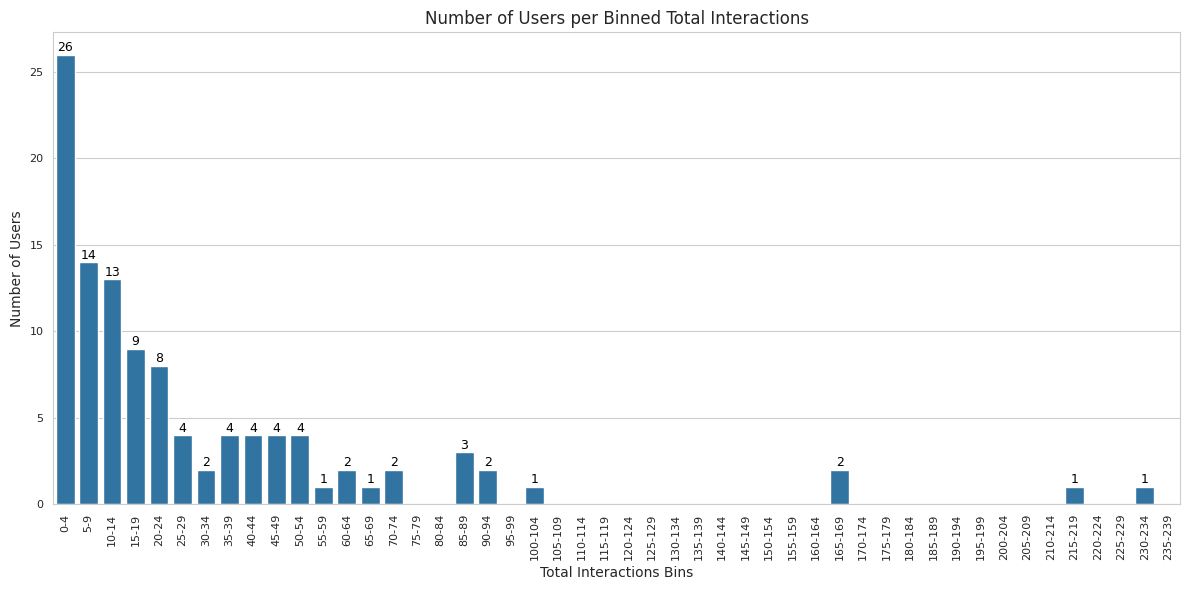

In [33]:
analyze_bar_graph(
    df=users_per_interactions_binned,
    x_col='Interaction_Bins',
    y_col='Number of Users',
    title='Number of Users per Binned Total Interactions',
    x_label='Total Interactions Bins',
    y_label='Number of Users',
    tick_label_size=8
)

In [36]:
# @title export md to Drive {"form-width":"20%"}
drive_folder_link = "https://drive.google.com/drive/folders/1MIIDzYnXAMdBqZGAolzgX_BwSk-zwSrJ?usp=drive_link" # @param {"type":"string"}
drive_folder_id = extract_file_id(drive_folder_link)
export_md_file = False # @param {"type":"boolean"}
interaction_threshold = "52" # @param {"type":"string","placeholder":"Enter threshold here"}
Course_name = "PH215 (online)" # @param {"type":"string","placeholder":"Enter Course here"}
notes = "" # @param {"type":"string","placeholder":"Enter Observation notes here"}

table_interactions = interactions_by_user[interactions_by_user['Total Interactions']>int(interaction_threshold)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
display(table_interactions)

if export_md_file:
  # Initialize selected_doc_url and selected_sheet_url if they are not defined
  # This handles the case where the cell is run before a specific lab is selected


  header_blocks=[
        f"interaction_threshold: {interaction_threshold}",
        "\n---\n\n"
        ]

  header_str = "\n".join(header_blocks)
  table_str = table_interactions.to_markdown(index=False)

  markdown_text = f"# Transcript Report\n\n{header_str}\n\n## User interactions by lab\n\n{table_str}\n\n Notes:\n\n{notes}"
  filename = f"Interactions_above_{interaction_threshold}-{Course_name}.md"

  # Upload to Google Drive if drive_folder_id is provided

  gdm = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)
  gdm.export_md(markdown_text, filename, drive_folder_id)
else:
  print("no file exported")


display(interactions_by_user[interactions_by_user['interactions']>795][['user','interactions']].sort_values(by=['interactions'], ascending=False))

KeyError: "['interactions'] not in index"

In [ ]:
# @title Total Interactions by Question Plot {"run":"auto","form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}

current_df = unexploded_df

interactions_by_lab = current_df.groupby(['Course', 'lab_number'])['interactions'].sum().reset_index()
interactions_by_lab.rename(columns={'interactions': 'interactions_by_lab'}, inplace=True)
# Create a combined question identifier for the x-axis labels if needed, or use existing columns
# interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
analyze_bar_graph(
    df=interactions_by_lab,
    x_col='lab_number',
    y_col='interactions_by_lab',
    title='Total Interactions per Lab',
    x_label='Lab',
    y_label='Total Interactions'
)
interactions_by_lab = interactions_by_lab.sort_values(by='interactions_by_lab', ascending=False)
display(interactions_by_lab[['lab_number','interactions_by_lab']])

In [ ]:
# @title last lab {"run":"auto","form-width":"20%"}
current_df = combined_df
filter_by_lab_number = "04" # @param ["01","02","03","04","05","06","07","08","False"] {"allow-input":true}


last_lab_per_user = current_df.groupby('user')['lab_number'].max().reset_index()
last_lab_per_user.rename(columns={'lab_number': 'last_lab_number'}, inplace=True)
if filter_by_lab_number != "False":
  last_lab_per_user = last_lab_per_user[last_lab_per_user['last_lab_number'] == filter_by_lab_number]

print("Last (highest) lab number for each user:")
display(last_lab_per_user.sort_values(by='last_lab_number', ascending=False))

In [ ]:
# from google.colab import sheets

# # @title Create Interactive Sheet and optionally move to a specific folder {"form-width":"20%"}
# move_to_target_folder = True # @param {type:"boolean"}
# target_folder_for_sheet_link = "https://drive.google.com/drive/folders/1KeIQKtAkXxhU6mB8uzd8Nw3_Ji7Oroyx?usp=drive_link" # @param {type:"string"}
# sheet_name = "transcript_analysis_Jan14" # @param {"type":"string"}

# # Create the interactive sheet
# sheet_object = sheets.InteractiveSheet(title=sheet_name, include_column_headers=True, df=combined_df)

# # Get the ID of the newly created sheet
# sheet_id = sheet_object.id
# print(f"Interactive Sheet created with ID: {sheet_id}")
# print(f"Interactive Sheet URL: {sheet_object.url}")

# if move_to_target_folder:
#   if 'GDM' not in globals():
#     GDM = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)

#   target_folder_id = extract_file_id(target_folder_for_sheet_link)
#   if target_folder_id:
#     try:
#       # Get current parent(s) to remove from
#       current_parents = GDM.get_file_parent_info(file_id=sheet_id)['parents']
#       current_parent_ids = [p['id'] for p in current_parents]

#       # Move the file by updating its parents
#       GDM.update_file_metadata(
#           file_id=sheet_id,
#           add_parents=target_folder_id,
#           remove_parents=','.join(current_parent_ids)
#       )
#       print(f"Successfully moved Interactive Sheet (ID: {sheet_id}) to folder (ID: {target_folder_id})")
#     except Exception as e:
#       print(f"Error moving sheet to target folder: {e}")
#       print("Please ensure the target folder link is valid and you have appropriate permissions.")
#   else:
#     print(f"Invalid target folder link provided: {target_folder_for_sheet_link}")


# summary

In [ ]:
len(unexploded_df['user'].unique())

In [ ]:
len(unexploded_df['thread'].unique())

In [ ]:
thread214 = unexploded_df[unexploded_df['Course']=="PH214 (online)"]['thread'].unique()
thread215 = unexploded_df[unexploded_df['Course']=="PH215 (online)"]['thread'].unique()

display(len(thread214))
display(len(thread215))

In [ ]:
current_df = unexploded_df

interactions214 = current_df[current_df['Course']=="PH214 (online)"]['interactions']
interactions215 = current_df[current_df['Course']=="PH215 (online)"]['interactions']

display(interactions214.describe())
display(interactions214.sum())

display(interactions215.describe())
display(interactions215.sum())

# Pivot the table to have courses as columns
interactions_pivot = interactions_by_user_and_course.pivot_table(
    index='user',
    columns='Course',
    values='interactions',
    fill_value=0 # Fill NaN values with 0 for users who didn't interact in a specific course
).reset_index()

In [ ]:
# Calculate interactions per user per course
interactions_by_user_and_course = current_df.groupby(['user', 'Course'])['interactions'].sum().reset_index()

# Pivot the table to have courses as columns
interactions_pivot = interactions_by_user_and_course.pivot_table(
    index='user',
    columns='Course',
    values='interactions',
    fill_value=0 # Fill NaN values with 0 for users who didn't interact in a specific course
).reset_index()

display(interactions_pivot)

In [ ]:
# @title export md to Drive {"form-width":"20%"}
drive_folder_link = "https://drive.google.com/drive/folders/1J-qxXeJvfq9MKQXAjJSg3OfJCNoDSmGw?usp=drive_link" # @param {"type":"string"}
drive_folder_id = extract_file_id(drive_folder_link)
export_md_file = True # @param {"type":"boolean"}


if export_md_file:
  # Initialize selected_doc_url and selected_sheet_url if they are not defined
  # This handles the case where the cell is run before a specific lab is selected

  title = "interactions"

  header_blocks=[
      f"# Transcript Report",
      "\n\n---\n\n",
      f"## {title}\n\n",
        ]

  header_str = "\n".join(header_blocks)
  table_str = df_course['interactions'].describe().to_markdown(index=True)

  markdown_text = f"{header_str}{table_str}\n\n Notes:\n\n{notes}"
  filename = title

  # Upload to Google Drive if drive_folder_id is provided

  gdm = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)
  gdm.export_md(markdown_text, filename, drive_folder_id)
else:
  print("no file exported")


# display(interactions_by_user[interactions_by_user['interactions']>795][['user','interactions']].sort_values(by=['interactions'], ascending=False))

In [ ]:
display(unexploded_df.columns)

In [37]:
import re

# Define the phrases to search for
phrases = ['partially correct', 'correct', 'partially incorrect', 'incorrect']

# Function to count occurrences of phrases in a list of messages
def count_phrases_in_messages(message_list, phrases_to_count):
    counts = {phrase: 0 for phrase in phrases_to_count}
    if not isinstance(message_list, list):
        return counts

    for message_dict in message_list:
        if isinstance(message_dict, dict) and 'text' in message_dict and 'sender' in message_dict and str(message_dict['sender']).lower() == 'bot':
            message_text = str(message_dict['text']).lower()
            for phrase in phrases_to_count:
                # Use regex with word boundaries to ensure exact phrase matching
                if re.search(r'\b' + re.escape(phrase) + r'\b', message_text):
                    counts[phrase] += 1
    return counts

# Apply the function to the 'all_messages' column and create new columns for counts
for phrase in phrases:
    unexploded_df[f'count_{phrase.replace(" ", "_")}'] = 0

for index, row in unexploded_df.iterrows():
    message_counts = count_phrases_in_messages(row['all_messages'], phrases)
    for phrase, count in message_counts.items():
        unexploded_df.at[index, f'count_{phrase.replace(" ", "_")}'] = count

print("Counts of specified phrases added to unexploded_df (only from bot messages):")
display(unexploded_df[[col for col in unexploded_df.columns if col.startswith('count_')]].head())

Counts of specified phrases added to unexploded_df (only from bot messages):


,count_partially_correct,count_correct,count_partially_incorrect,count_incorrect
1,0,1,0,0
2,0,0,0,0
3,0,2,0,0
4,0,1,0,0
5,0,1,0,1


In [50]:
print("Rows where 'correct' count is 0, but other counts are > 0:")
uncorrected_df = unexploded_df[
    (unexploded_df['count_correct'] < 1)
    & (
        (unexploded_df['count_partially_correct'] > 0)
        | (unexploded_df['count_partially_incorrect'] > 0)
        | (unexploded_df['count_incorrect'] > 0)
      )
    # & (unexploded_df['interactions']>1)
][['user', 'Course', 'lab_number', 'question_number', 'interactions', 'count_partially_correct', 'count_correct', 'count_partially_incorrect', 'count_incorrect']]

display(len(uncorrected_df))
display(uncorrected_df.sort_values(by='interactions', ascending=False))

Rows where 'correct' count is 0, but other counts are > 0:


37

,user,Course,lab_number,question_number,interactions,count_partially_correct,count_correct,count_partially_incorrect,count_incorrect
351,203,PH214 (online),08,00,7.0,0,0,0,1
374,203,PH214 (online),07,00,6.0,0,0,0,1
648,225,PH214 (online),01,06,6.0,0,0,0,1
651,225,PH214 (online),03,05,3.0,0,0,0,1
832,159,PH214 (online),06,08,3.0,0,0,0,1
1536,325,PH215 (online),01,05,3.0,0,0,0,1
1669,314,PH215 (online),02,02,2.0,0,0,0,1
1661,314,PH215 (online),01,04,2.0,0,0,0,1
1553,281,PH215 (online),01,05,2.0,0,0,0,1
160,182,PH214 (online),01,02,2.0,0,0,0,1


In [51]:
display(
  unexploded_df['count_correct'].value_counts(),
  unexploded_df['count_partially_correct'].value_counts(),
  unexploded_df['count_partially_incorrect'].value_counts(),
  unexploded_df['count_incorrect'].value_counts()
)


,count
count_correct,
1,611
0,599
2,156
3,44
4,23
5,10
6,5
8,3
11,2


,count
count_partially_correct,
0,1221
1,165
2,44
3,12
4,9
5,4
6,1
7,1


,count
count_partially_incorrect,
0,1456
1,1


,count
count_incorrect,
0,1282
1,141
2,20
3,8
4,4
5,1
9,1


In [66]:
from IPython.display import display, Markdown
for respsonse in unexploded_df[unexploded_df['count_partially_incorrect'] >0].iloc[0]['all_messages']:
  display(Markdown(f"## {respsonse['sender']}"))
  display(Markdown(f"### text:\n {respsonse['text']}"))
  if respsonse['sender'] == 'Bot':
    display(Markdown(f"\n\n---\n\n"))


## You

### text:
 ∆t = +- 0.005 s, ∆y = 0.002m

## Bot

### text:
 Partially correct. The manual asks for your new estimated uncertainties for ∆t and ∆y (§Q7) .

Comments:
- ∆t = ±0.005 s is reasonable if you used a high-frame-rate camera (or phyphox/auditory methods) with ≳200 fps or equivalent timing resolution.  
- ∆y = ±0.002 m is optimistic unless you have a mm-resolution measuring tool and a well-defined reference (center of mass, repeatable contact point); otherwise ±0.005–0.01 m is more typical.

Justify the values in your report (method, instrument resolution, and any systematic offsets).

Quick check: What method did you use to measure ∆t? How did you measure ∆y (tool and reference points)?



---



...

## You

### text:
 Yes please

## Bot

### text:
 ∆t measured from 240 fps video with Tracker sub‑frame interpolation → uncertainty ±0.002 s (≈half a frame); ∆y measured from desk top to ball center with a 30 cm ruler (1 mm markings) → baseline uncertainty ±0.0005 m increased to ±0.002 m due to alignment issues and no repeat measurements, consistent with the manual’s guidance to use slow‑motion/frame counting and half the smallest division as a baseline while justifying any larger estimate .

Would you like this phrased more formally for the report?



---



In [ ]:
for test in unexploded_df[unexploded_df['count_correct']==10]['all_messages'].iloc[0];
  print()